<a href="https://colab.research.google.com/github/marcovirulucas/econ_apis/blob/main/world/World_Bank.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# World Bank Indicators API with Python
## External debt stocks (% of GNI)
------
*March 6, 2026*\
\
The World Bank Indicators API documentation can be found [here](https://datahelpdesk.worldbank.org/knowledgebase/articles/889392-about-the-indicators-api-documentation), and the basic call structures are available [here](https://datahelpdesk.worldbank.org/knowledgebase/articles/898581-api-basic-call-structures).\
\
This script collects data on External debt stocks (as a percentage of Gross National Income) for a selection of Latin American countries.

In [1]:
import requests
import pandas as pd

### Parameter/Settings

In [2]:
base = 'http://api.worldbank.org/v2/country/'

In [3]:
# Parameters
countries = 'bra;per;mex;col'
indicator = 'DT.DOD.DECT.GN.ZS'
dates= '2000:2024'
per_page = 100
url = f'{base}{countries}/indicators/{indicator}?date={dates}&per_page={per_page}&format=json'

In [4]:
url

'http://api.worldbank.org/v2/country/bra;per;mex;col/indicators/DT.DOD.DECT.GN.ZS?date=2000:2024&per_page=100&format=json'

### Request the data

In [5]:
# Make a request to an URL and store the JSON data in a dictionary format
r = requests.get(url).json()

Previously, we established the parameter ***per_page = 100***. In our initial attempt, without this parameter, the API returned data across 2 pages of 50 results each, leaving the dataframe incomplete because the ***object r*** only captured the first page.

To avoid this, first calculate the total expected observations (in this case 100, representing 4 countries over 25 years) and set *per_page* to at least that value.

You can verify the number of pages, results per page, and total observations within the *object r* by running the following statements:

In [6]:
result_pages = r[0]['pages'] # Result pages in r
results_per_page = r[0]['per_page'] # Results per page in r
total_results = r[0]['total'] # Total results in r

After we established the parameter ***per_page = 100***,  the API returned data across 1 page with 100 results, the number of total expected observations.

In [7]:
print(result_pages)
print(results_per_page)
print(total_results)

1
100
100


In [8]:
# Construct the dataframe
country_names = list(set([i['country']['value'] for i in r[1]]))
title = r[1][0]['indicator']['value']

df = (pd.DataFrame({country: pd.Series({pd.to_datetime(f"{i['date']}-01-01"): i['value']
                                        for i in r[1]
                                        if i['country']['value'] == country})
                    for country in country_names})
        .astype('float')
        .sort_index())

In [9]:
df.tail()

,Brazil,Peru,Mexico,Colombia
2020-01-01,38.007665,38.178030,56.834966,58.195276
2021-01-01,35.291013,42.607166,46.896578,54.570253
2022-01-01,30.562118,39.978891,40.897191,55.290160
2023-01-01,28.628650,37.197566,34.072289,54.969814
2024-01-01,28.661266,34.228221,32.892052,49.203870


### Plot the results

In [10]:
import matplotlib.pyplot as plt
plt.style.use('seaborn-v0_8-white')
plt.rc('axes', edgecolor='white', axisbelow=True)

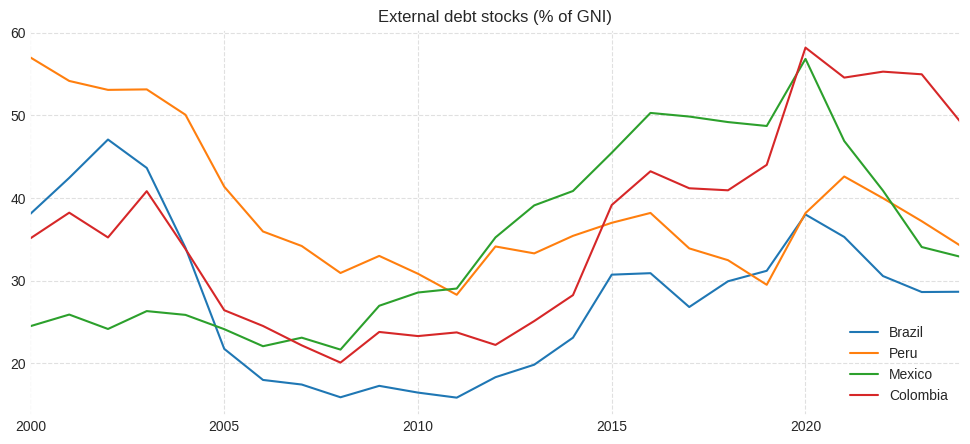

In [11]:
df.plot(figsize=(12, 5))
plt.title('External debt stocks (% of GNI)')
plt.grid(True, linestyle='--', alpha=0.6)
plt.show()